In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Section 1: Data Loading and Inspection

In [3]:
#Load the dataset as a Pandas DataFrame.
#Display the first 5 records and check the shape of the dataset

df = pd.read_excel("Sales.xlsx")
df.head(5)

,Order_ID,Order_Date,Region,Salesperson,Product_Category,Product,Units_Sold,Unit_Price,Discount,Target,Customer_Segment
0,1001,2023-01-03,North,Ravi,Electronics,Laptop,5,70000,0.05,300000,Corporate
1,1002,2023-01-05,South,Ananya,Furniture,Chair,12,3500,0.10,35000,Consumer
2,1003,2023-01-10,East,Neha,Electronics,Mobile,8,25000,0.08,150000,Small Business
3,1004,2023-01-12,West,Aryan,Stationery,Notebook,30,120,0.00,5000,Consumer
4,1005,2023-02-02,North,Meera,Furniture,Table,3,12000,0.10,40000,Corporate


In [4]:
# Check for missing values in each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          10 non-null     int64         
 1   Order_Date        10 non-null     datetime64[ns]
 2   Region            10 non-null     object        
 3   Salesperson       10 non-null     object        
 4   Product_Category  10 non-null     object        
 5   Product           10 non-null     object        
 6   Units_Sold        10 non-null     int64         
 7   Unit_Price        10 non-null     int64         
 8   Discount          10 non-null     float64       
 9   Target            10 non-null     int64         
 10  Customer_Segment  10 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 1012.0+ bytes


In [5]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Region              0
Salesperson         0
Product_Category    0
Product             0
Units_Sold          0
Unit_Price          0
Discount            0
Target              0
Customer_Segment    0
dtype: int64

## There are no Missing Values 

In [6]:
# Convert the “Order_Date” column to datetime type.
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          10 non-null     int64         
 1   Order_Date        10 non-null     datetime64[ns]
 2   Region            10 non-null     object        
 3   Salesperson       10 non-null     object        
 4   Product_Category  10 non-null     object        
 5   Product           10 non-null     object        
 6   Units_Sold        10 non-null     int64         
 7   Unit_Price        10 non-null     int64         
 8   Discount          10 non-null     float64       
 9   Target            10 non-null     int64         
 10  Customer_Segment  10 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 1012.0+ bytes


In [8]:
# Print all unique “Regions” and “Product_Category” values
unique_region = df["Region"].unique()
unique_product_category = df["Product_Category"].unique()
print("Unique Values of Region :\n", unique_region)
print("Unique Values of Product Category :\n", unique_product_category)

Unique Values of Region :
 ['North' 'South' 'East' 'West']
Unique Values of Product Category :
 ['Electronics' 'Furniture' 'Stationery']


In [9]:
# Display records where Discount > 0.1
df[df["Discount"] > 0.1]

,Order_ID,Order_Date,Region,Salesperson,Product_Category,Product,Units_Sold,Unit_Price,Discount,Target,Customer_Segment
5,1006,2023-02-05,East,Rohan,Electronics,Headphones,10,2000,0.15,20000,Consumer
9,1010,2023-03-10,South,Aryan,Furniture,Chair,10,4000,0.12,40000,Consumer


In [10]:
# Find the minimum and maximum order date
min_order_date = df["Order_Date"].min()
max_order_date = df["Order_Date"].max()
print("Minimum Order Date is :", min_order_date)
print("Maximum Order Date is :", max_order_date)

Minimum Order Date is : 2023-01-03 00:00:00
Maximum Order Date is : 2023-03-10 00:00:00


In [11]:
# Display summary statistics for Units_Sold, Unit_Price, and Revenue (after calculation).
df["Revenue"] = df["Units_Sold"] * df["Unit_Price"]
df[["Units_Sold", "Unit_Price", "Revenue"]].describe()

,Units_Sold,Unit_Price,Revenue
count,10.000000,10.000000,10.00000
mean,12.300000,21367.000000,95960.00000
std,12.658331,27778.448901,117685.90211
min,2.000000,50.000000,2000.00000
25%,3.500000,2375.000000,24000.00000
50%,9.000000,8000.000000,41000.00000
75%,11.500000,25000.000000,162500.00000
max,40.000000,72000.000000,350000.00000


### Section 2: Data Transformation and Feature Engineering

In [12]:
# Add a new column Revenue = Units_Sold * Unit_Price * (1 - Discount).
df["Revenue"] = df["Units_Sold"] * df["Unit_Price"] * (1-df["Discount"])

In [13]:
df.head()

,Order_ID,Order_Date,Region,Salesperson,Product_Category,Product,Units_Sold,Unit_Price,Discount,Target,Customer_Segment,Revenue
0,1001,2023-01-03,North,Ravi,Electronics,Laptop,5,70000,0.05,300000,Corporate,332500.0
1,1002,2023-01-05,South,Ananya,Furniture,Chair,12,3500,0.10,35000,Consumer,37800.0
2,1003,2023-01-10,East,Neha,Electronics,Mobile,8,25000,0.08,150000,Small Business,184000.0
3,1004,2023-01-12,West,Aryan,Stationery,Notebook,30,120,0.00,5000,Consumer,3600.0
4,1005,2023-02-02,North,Meera,Furniture,Table,3,12000,0.10,40000,Corporate,32400.0


In [14]:
# Add a column Month extracted from the Order_Date
df["Month"] = df["Order_Date"].dt.month_name()

In [15]:
df.head()

,Order_ID,Order_Date,Region,Salesperson,Product_Category,Product,Units_Sold,Unit_Price,Discount,Target,Customer_Segment,Revenue,Month
0,1001,2023-01-03,North,Ravi,Electronics,Laptop,5,70000,0.05,300000,Corporate,332500.0,January
1,1002,2023-01-05,South,Ananya,Furniture,Chair,12,3500,0.10,35000,Consumer,37800.0,January
2,1003,2023-01-10,East,Neha,Electronics,Mobile,8,25000,0.08,150000,Small Business,184000.0,January
3,1004,2023-01-12,West,Aryan,Stationery,Notebook,30,120,0.00,5000,Consumer,3600.0,January
4,1005,2023-02-02,North,Meera,Furniture,Table,3,12000,0.10,40000,Corporate,32400.0,February


In [16]:
# Add a column Performance = “Achieved” if Revenue >= Target, else “Not Achieved”.
df["Performance"] = np.where(df["Revenue"]>=df["Target"],"Achieved","Not Achieved")

In [17]:
df.head()

,Order_ID,Order_Date,Region,Salesperson,Product_Category,Product,Units_Sold,Unit_Price,Discount,Target,Customer_Segment,Revenue,Month,Performance
0,1001,2023-01-03,North,Ravi,Electronics,Laptop,5,70000,0.05,300000,Corporate,332500.0,January,Achieved
1,1002,2023-01-05,South,Ananya,Furniture,Chair,12,3500,0.10,35000,Consumer,37800.0,January,Achieved
2,1003,2023-01-10,East,Neha,Electronics,Mobile,8,25000,0.08,150000,Small Business,184000.0,January,Achieved
3,1004,2023-01-12,West,Aryan,Stationery,Notebook,30,120,0.00,5000,Consumer,3600.0,January,Not Achieved
4,1005,2023-02-02,North,Meera,Furniture,Table,3,12000,0.10,40000,Corporate,32400.0,February,Not Achieved


In [18]:
# Add a column Profit = 0.2 × Revenue (assuming 20% profit margin).
df["Profit"] = df["Revenue"] * 0.2

In [19]:
df.head()

,Order_ID,Order_Date,Region,Salesperson,Product_Category,Product,Units_Sold,Unit_Price,Discount,Target,Customer_Segment,Revenue,Month,Performance,Profit
0,1001,2023-01-03,North,Ravi,Electronics,Laptop,5,70000,0.05,300000,Corporate,332500.0,January,Achieved,66500.0
1,1002,2023-01-05,South,Ananya,Furniture,Chair,12,3500,0.10,35000,Consumer,37800.0,January,Achieved,7560.0
2,1003,2023-01-10,East,Neha,Electronics,Mobile,8,25000,0.08,150000,Small Business,184000.0,January,Achieved,36800.0
3,1004,2023-01-12,West,Aryan,Stationery,Notebook,30,120,0.00,5000,Consumer,3600.0,January,Not Achieved,720.0
4,1005,2023-02-02,North,Meera,Furniture,Table,3,12000,0.10,40000,Corporate,32400.0,February,Not Achieved,6480.0


In [20]:
# Calculate total revenue per salesperson using groupby().
t_r_p_s = df.groupby("Salesperson")["Revenue"].sum()
print("Total Revenue Per Sales-Person :\n","========================= \n", t_r_p_s)

Total Revenue Per Sales-Person :
 Salesperson
Ananya     37800.0
Aryan      38800.0
Isha        2000.0
Meera      32400.0
Neha      231500.0
Ravi      537700.0
Rohan      17000.0
Name: Revenue, dtype: float64


In [21]:
# Find average discount offered in each region.
a_d_p_r = df.groupby("Region")["Discount"].mean().round(2)
print("Average Discount Offered in Each Region :\n", "========================== \n", a_d_p_r)

Average Discount Offered in Each Region :
 Region
East     0.12
North    0.07
South    0.07
West     0.02
Name: Discount, dtype: float64


In [22]:
# For each Product_Category, calculate total units sold
u_c_p_c = df.groupby("Product_Category")["Units_Sold"].sum()
print("Total Units Sold For Each Product Category :\n", "======================= \n", u_c_p_c)

Total Units Sold For Each Product Category :
 Product_Category
Electronics    26
Furniture      27
Stationery     70
Name: Units_Sold, dtype: int64


In [23]:
# Identify the top 3 products by total revenue
top_3products = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)
print("Top 3 Products by Total Revenue :\n", "======================\n", top_3products.head(3))

Top 3 Products by Total Revenue :
 Product
Laptop    537700.0
Mobile    184000.0
Chair      73000.0
Name: Revenue, dtype: float64


In [24]:
# Find the salesperson with the highest cumulative revenue
top_salesperson = df.groupby("Salesperson")["Revenue"].sum().sort_values(ascending=False)
print("The Sales Person With the Highest Revenue is :\n","-------------------\n", top_salesperson.head(1))

The Sales Person With the Highest Revenue is :
 -------------------
 Salesperson
Ravi    537700.0
Name: Revenue, dtype: float64


In [25]:
# Identify which region has the lowest average revenue per order
lowest_region = df.groupby("Region")["Revenue"].mean().sort_values(ascending=True)
print("The Lowest Average Revenue Region is :\n","---------------------------\n", lowest_region.head(1))

The Lowest Average Revenue Region is :
 ---------------------------
 Region
South    25000.0
Name: Revenue, dtype: float64


### Section 3: Sales Target and Performance Analysis

In [26]:
# For each region, calculate total Revenue and total Target.
region_wise_ = df.groupby("Region")[["Revenue","Target"]].sum()
print("Region Wise Total Revenue and Total Target :\n","============================\n", region_wise_)

Region Wise Total Revenue and Total Target :
          Revenue  Target
Region                  
East    201000.0  170000
North   570100.0  590000
South    75000.0   78000
West     51100.0   65000


In [27]:
# Add a column Target_Difference = Revenue - Target and display top 5 results.
df["Target_Difference"] = df["Revenue"] - df["Target"]
df.sort_values("Target_Difference", ascending=False).head(5)

,Order_ID,Order_Date,Region,Salesperson,Product_Category,Product,Units_Sold,Unit_Price,Discount,Target,Customer_Segment,Revenue,Month,Performance,Profit,Target_Difference
2,1003,2023-01-10,East,Neha,Electronics,Mobile,8,25000,0.08,150000,Small Business,184000.0,January,Achieved,36800.0,34000.0
0,1001,2023-01-03,North,Ravi,Electronics,Laptop,5,70000,0.05,300000,Corporate,332500.0,January,Achieved,66500.0,32500.0
1,1002,2023-01-05,South,Ananya,Furniture,Chair,12,3500,0.10,35000,Consumer,37800.0,January,Achieved,7560.0,2800.0
6,1007,2023-02-08,South,Isha,Stationery,Pen,40,50,0.00,3000,Small Business,2000.0,February,Not Achieved,400.0,-1000.0
3,1004,2023-01-12,West,Aryan,Stationery,Notebook,30,120,0.00,5000,Consumer,3600.0,January,Not Achieved,720.0,-1400.0


In [28]:
#Find how many salespersons met or exceeded their targets
met_target = df[df["Revenue"] >= df["Target"]]
count_met_target = met_target["Salesperson"].count()
print("Count of Sales Person Met Their targets :", count_met_target)

Count of Sales Person Met Their targets : 3


In [29]:
# Calculate the target achievement percentage for each region
achievement_pct = df.groupby('Region')['Performance'].apply(lambda x: (x == 'Achieved').mean() * 100)
print("Achievment Percentage for Each Region :\n", achievement_pct)

Achievment Percentage for Each Region :
 Region
East     50.000000
North    33.333333
South    33.333333
West      0.000000
Name: Performance, dtype: float64


In [30]:
# Find which Product_Category achieved the highest percentage of targets
df["Target_Percentage"] = (df["Revenue"] / df["Target"]) * 100
highest_product = df.groupby("Product_Category")["Target_Percentage"].mean().round(2)
highest_product.sort_values(ascending=False)
print("The product achiieved the highest percentage of targets :\n", highest_product.head(1))

The product achiieved the highest percentage of targets :
 Product_Category
Electronics    100.14
Name: Target_Percentage, dtype: float64


In [31]:
df.head(5)

,Order_ID,Order_Date,Region,Salesperson,Product_Category,Product,Units_Sold,Unit_Price,Discount,Target,Customer_Segment,Revenue,Month,Performance,Profit,Target_Difference,Target_Percentage
0,1001,2023-01-03,North,Ravi,Electronics,Laptop,5,70000,0.05,300000,Corporate,332500.0,January,Achieved,66500.0,32500.0,110.833333
1,1002,2023-01-05,South,Ananya,Furniture,Chair,12,3500,0.10,35000,Consumer,37800.0,January,Achieved,7560.0,2800.0,108.000000
2,1003,2023-01-10,East,Neha,Electronics,Mobile,8,25000,0.08,150000,Small Business,184000.0,January,Achieved,36800.0,34000.0,122.666667
3,1004,2023-01-12,West,Aryan,Stationery,Notebook,30,120,0.00,5000,Consumer,3600.0,January,Not Achieved,720.0,-1400.0,72.000000
4,1005,2023-02-02,North,Meera,Furniture,Table,3,12000,0.10,40000,Corporate,32400.0,February,Not Achieved,6480.0,-7600.0,81.000000


In [32]:
# For each Customer_Segment, calculate total sales and total target
customer_segment = df.groupby("Customer_Segment")[["Revenue","Target"]].sum()
print("Toal Sales and Target for Each Customer_Segment :\n", customer_segment)

Toal Sales and Target for Each Customer_Segment :
                    Revenue  Target
Customer_Segment                  
Consumer           93600.0  100000
Corporate         617600.0  650000
Small Business    186000.0  153000


In [33]:
# Identify which month had the highest target achievement rate
highest_month = df.groupby("Month")["Target_Percentage"].mean().round(2).sort_values(ascending=False)
print("The Month had the highest target achivement rate :\n", highest_month.head(1))

The Month had the highest target achivement rate :
 Month
January    103.38
Name: Target_Percentage, dtype: float64


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order_ID           10 non-null     int64         
 1   Order_Date         10 non-null     datetime64[ns]
 2   Region             10 non-null     object        
 3   Salesperson        10 non-null     object        
 4   Product_Category   10 non-null     object        
 5   Product            10 non-null     object        
 6   Units_Sold         10 non-null     int64         
 7   Unit_Price         10 non-null     int64         
 8   Discount           10 non-null     float64       
 9   Target             10 non-null     int64         
 10  Customer_Segment   10 non-null     object        
 11  Revenue            10 non-null     float64       
 12  Month              10 non-null     object        
 13  Performance        10 non-null     object        
 14  Profit       

In [35]:
# Find the correlation between Discount and Revenue
correlation = df["Discount"].corr(df["Revenue"])
correlation

np.float64(-0.10165887622157682)

#### Correlation is Negative,So Discount and Revenue both are increase or decrease in the opposite direction

In [36]:
# Save the region-wise target performance summary to a new CSV file
region_summary = df.groupby("Region")[["Revenue","Target"]].sum()
region_summary["Region wise target performance"] = round((region_summary["Revenue"] / region_summary["Target"])*100,2)
region_summary["Region wise target performance"]
print(region_summary)

         Revenue  Target  Region wise target performance
Region                                                  
East    201000.0  170000                          118.24
North   570100.0  590000                           96.63
South    75000.0   78000                           96.15
West     51100.0   65000                           78.62


In [92]:
region_summary.to_csv("Region_wise_target_summary.csv")
print("@@@@ New CSV File Save Sucesfully @@@@")

@@@@ New CSV File Save Sucesfully @@@@


## Visualization

In [37]:
df.head(5)

,Order_ID,Order_Date,Region,Salesperson,Product_Category,Product,Units_Sold,Unit_Price,Discount,Target,Customer_Segment,Revenue,Month,Performance,Profit,Target_Difference,Target_Percentage
0,1001,2023-01-03,North,Ravi,Electronics,Laptop,5,70000,0.05,300000,Corporate,332500.0,January,Achieved,66500.0,32500.0,110.833333
1,1002,2023-01-05,South,Ananya,Furniture,Chair,12,3500,0.10,35000,Consumer,37800.0,January,Achieved,7560.0,2800.0,108.000000
2,1003,2023-01-10,East,Neha,Electronics,Mobile,8,25000,0.08,150000,Small Business,184000.0,January,Achieved,36800.0,34000.0,122.666667
3,1004,2023-01-12,West,Aryan,Stationery,Notebook,30,120,0.00,5000,Consumer,3600.0,January,Not Achieved,720.0,-1400.0,72.000000
4,1005,2023-02-02,North,Meera,Furniture,Table,3,12000,0.10,40000,Corporate,32400.0,February,Not Achieved,6480.0,-7600.0,81.000000


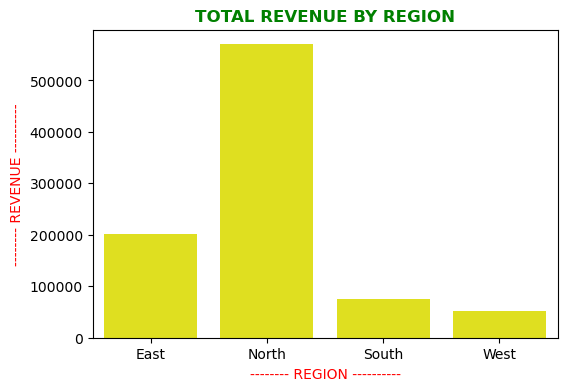

In [84]:
# Plot total Revenue by Region as a bar chart
region_total_revenue = df.groupby("Region")["Revenue"].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data= region_total_revenue, x = "Region", y = "Revenue", color = "yellow")
plt.title("TOTAL REVENUE BY REGION", color = "green", fontweight="bold")
plt.xlabel("-------- REGION ----------", color = "red")
plt.ylabel("-------- REVENUE ----------", color = "red")
plt.show() 

### Total Revenue is higher in North Region, Medium in East Region and Lower in South and West Region

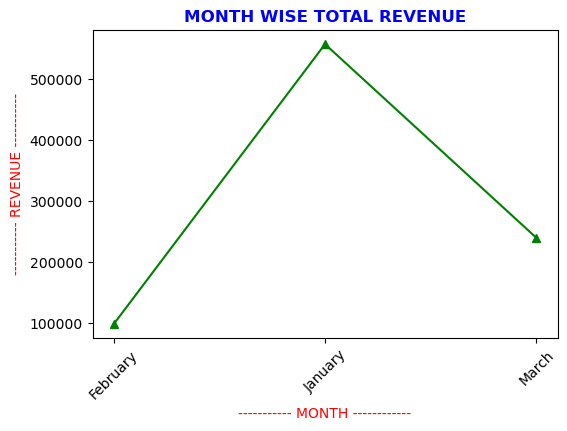

In [83]:
# Plot a line chart of monthly total Revenue trends.
monthly_revenue = df.groupby("Month")["Revenue"].sum().reset_index()
plt.figure(figsize=(6,4))
plt.plot(monthly_revenue["Month"], monthly_revenue["Revenue"], color="green", marker="^")
plt.title("MONTH WISE TOTAL REVENUE", color="blue", fontweight="bold")
plt.xlabel("----------- MONTH ------------", color="red")
plt.ylabel("----------- REVENUE -----------", color="red")
plt.xticks(rotation=45)
plt.show()

### High revenue earned in January Month

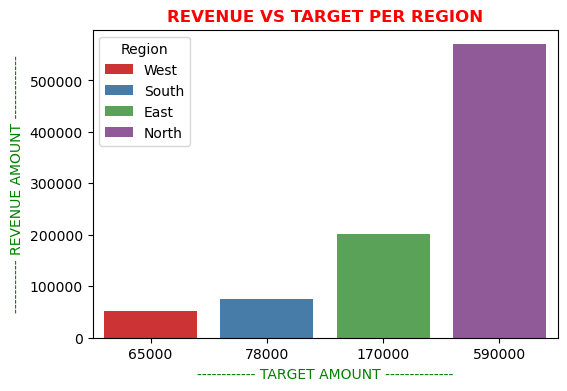

In [82]:
# Create a bar chart comparing Target vs Actual Revenue per region
region_summary = df.groupby("Region")[["Revenue","Target"]].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=region_summary, x="Target", y="Revenue", hue="Region", palette="Set1")
plt.title("REVENUE VS TARGET PER REGION", color="red", fontweight="bold")
plt.xlabel("------------ TARGET AMOUNT --------------", color="green")
plt.ylabel("----------- REVENUE AMOUNT -------------", color="green")
plt.show()

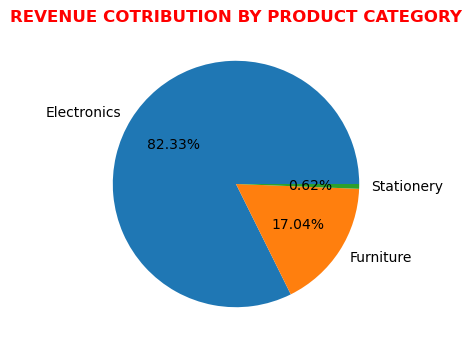

In [81]:
# Plot a pie chart showing revenue contribution by Product_Category
category_revenue = df.groupby("Product_Category")["Revenue"].sum()
plt.figure(figsize=(6,4))
plt.pie(category_revenue, labels=category_revenue.index, autopct="%1.2f%%")
plt.title("REVENUE COTRIBUTION BY PRODUCT CATEGORY", color="red", fontweight="bold")
plt.show()

#### Electronics category product are high contribution in Revenue and Stationary category product are low conttribution

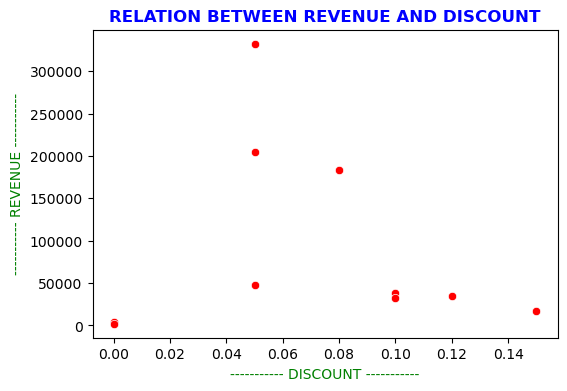

In [80]:
# Create a scatter plot between Discount and Revenue
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Discount", y="Revenue", color="red")
plt.title("RELATION BETWEEN REVENUE AND DISCOUNT", color="blue", fontweight="bold")
plt.xlabel("----------- DISCOUNT -----------", color="green")
plt.ylabel("----------- REVENUE -----------", color="green")
plt.show()

<Figure size 600x400 with 0 Axes>

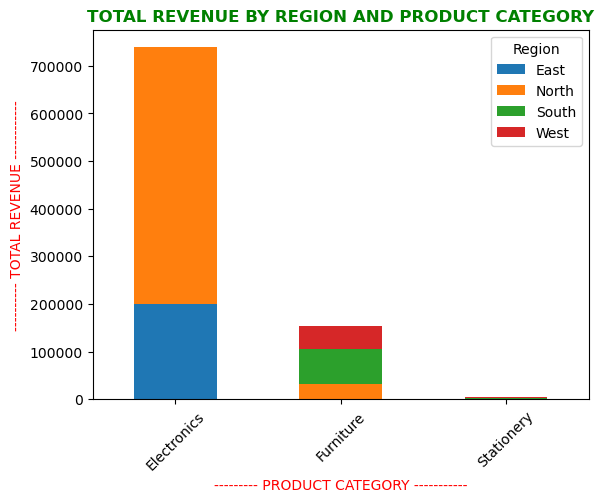

In [79]:
# Create a stacked bar chart showing total revenue by region split by Product_Category.
grouped_revenue = df.groupby(["Region", "Product_Category"])["Revenue"].sum().reset_index()
pivot_df = grouped_revenue.pivot(index="Product_Category", columns="Region", values="Revenue")
plt.figure(figsize=(6,4))
pivot_df.plot(kind="bar", stacked=True)
plt.title("TOTAL REVENUE BY REGION AND PRODUCT CATEGORY", color="green", fontweight="bold")
plt.xlabel("--------- PRODUCT CATEGORY -----------", color="red")
plt.ylabel("---------- TOTAL REVENUE ------------", color="red")
plt.legend(title="Region")
plt.xticks(rotation=45)
plt.show()

### Total revenue of Electronics category product are high in North region and Medium in East region.
### Total revenue of Furniture category product are average in North, South and West region.
### total revenue of Stationery category product are  very low in all region. 

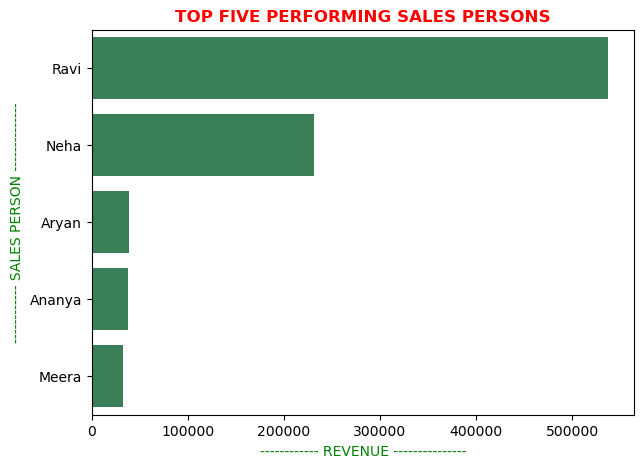

In [78]:
# Highlight top 5 performing salespersons in a horizontal bar chart and Save your best chart as sales_dashboard.png
top5 = df.groupby("Salesperson")["Revenue"].sum().reset_index().sort_values(by="Revenue",ascending=False).head(5)
plt.figure(figsize=(7,5))
sns.barplot(data=top5, x="Revenue", y="Salesperson", color="seagreen")
plt.title("TOP FIVE PERFORMING SALES PERSONS", color="red", fontweight="bold")
plt.xlabel("------------ REVENUE ---------------", color="green")
plt.ylabel("------------ SALES PERSON --------------", color="green")
plt.savefig("sales_dashboard.png")
plt.show()

### Here top best performing sales person is Ravi and next is Neha.
### Aryan, Ananya and Meera are average performing Sales Persons.

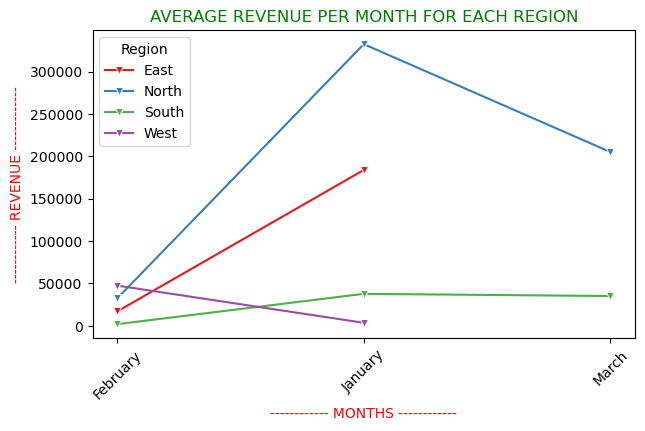

In [72]:
# Plot average revenue per month for each region in a single line plot.
monthly_avg_region = df.groupby(["Month","Region"])["Revenue"].mean().reset_index()
plt.figure(figsize=(7,4))
sns.lineplot(data=monthly_avg_region, x="Month", y="Revenue", hue="Region", marker="v", palette="Set1")
plt.title("AVERAGE REVENUE PER MONTH FOR EACH REGION", color="green")
plt.xlabel("------------ MONTHS ------------", color="red")
plt.ylabel("------------ REVENUE -------------", color="red")
plt.xticks(rotation=45)
plt.show()

### For North region, average revenue is high in January and March months, and lower in February Month.
### For east region, average revenue is medium high in January month and lower in February month.
### For South and West region , average revenue is lower in these three months.